<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [5]:
from google.colab import files
uploaded = files.upload()


# Carregar a base de dados
df = pd.read_csv("CARRO_CLIENTES.csv")

# Verificar tipos de dados
tipos = df.dtypes

# Verificar dados faltantes
faltantes = df.isnull().sum()

# Remover coluna ID
df = df.drop(columns=["User ID"])


Saving CARRO_CLIENTES.csv to CARRO_CLIENTES.csv


In [6]:
# Aplicar Label Encoder
le = LabelEncoder()
df["Gender_encoded"] = le.fit_transform(df["Gender"])

# Remover coluna categórica original
df = df.drop(columns=["Gender"])


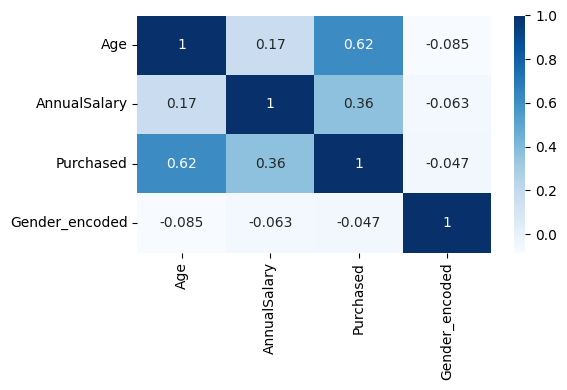

In [7]:
# Matriz de correlação
corr = df.corr()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.tight_layout()


A renda anual é o fator que mais se relaciona com a decisão de compra. Clientes com salários mais altos tendem a comprar com maior frequência. A idade também mostra uma relação positiva, embora menos intensa do que a renda. Já o gênero praticamente não influencia o comportamento de compra, apresentando correlação muito baixa com o target.

In [8]:
# Separação entre X e y
X = df.drop(columns=["Purchased"])
y = df["Purchased"]

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


In [10]:
# Converter os dados de treino para o formato DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)

# Parâmetros do modelo
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.05,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

# Treinamento
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300
)


In [12]:
dtest = xgb.DMatrix(X_test)

# Probabilidades previstas (classe positiva = 1)
y_proba = model.predict(dtest)

# Transformar probabilidades em classes (0 ou 1)
y_pred = (y_proba >= 0.5).astype(int)



In [13]:
# Transformar probabilidades em previsões binárias
y_pred = (y_proba >= 0.5).astype(int)

# Avaliação do modelo
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)


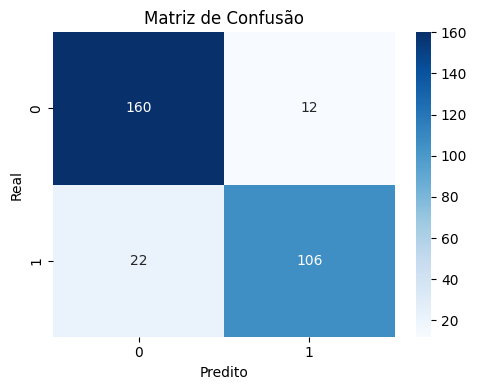

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.tight_layout()


O gráfico mostra como o modelo se saiu ao classificar os clientes. É possível ver quantas previsões ele acertou para quem realmente não comprou e para quem comprou. A maior parte dos acertos está concentrada na classe “não comprou”, indicando que o modelo tem mais facilidade em identificar esse grupo. Já os erros aparecem quando o modelo confunde alguns compradores com não compradores, o que é comum quando a base tem mais exemplos de uma classe do que da outra.

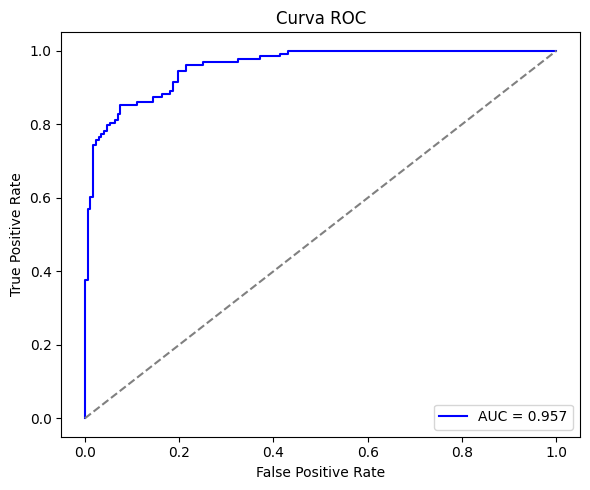

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.tight_layout()



A curva ROC mostra o quanto o modelo consegue separar corretamente quem compra de quem não compra. Quanto mais a linha se afasta da diagonal, melhor é o desempenho. No gráfico, a curva sobe rapidamente, indicando que o modelo tem uma boa taxa de verdadeiros positivos mesmo mantendo os falsos positivos baixos. O valor de AUC reforça essa interpretação, mostrando que o modelo tem uma capacidade razoável de distinguir as duas classes.

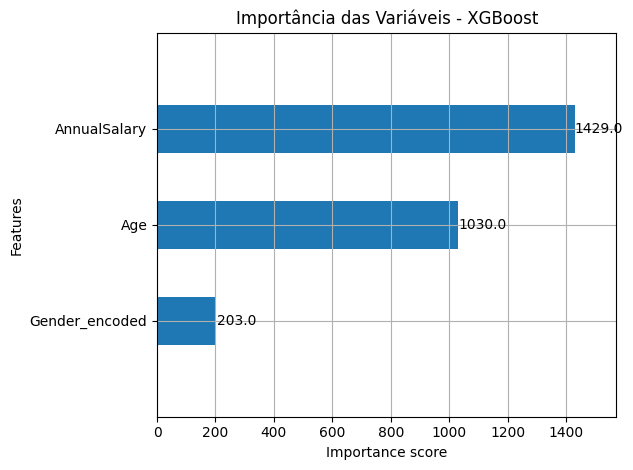

In [17]:
xgb.plot_importance(model, max_num_features=10, height=0.5)
plt.title("Importância das Variáveis - XGBoost")
plt.tight_layout()


O gráfico de importância deixa claro quais variáveis mais influenciam as decisões do modelo. A renda anual(Annual Salary) aparece como o fator mais relevante, seguida pela idade(age). Essas duas variáveis são as que mais ajudam o modelo a identificar padrões de compra. Já o gênero(Gender_encoded) tem impacto muito pequeno, praticamente irrelevante para a previsão. Isso confirma a análise inicial da correlação e mostra que o modelo se apoia principalmente em características socioeconômicas.

In [18]:
# Importância das variáveis
importance = model.get_score(importance_type='weight')

# Transformar em DataFrame para organizar melhor
feature_importance = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
}).sort_values(by='Importance', ascending=False)


A análise da importância das variáveis mostra claramente quais características mais influenciam o modelo. A renda anual aparece no topo, sendo o fator que mais pesa nas decisões do algoritmo. Em seguida vem a idade, que também contribui, mas com impacto menor. Já o gênero praticamente não interfere no resultado, aparecendo com relevância muito baixa. Isso confirma que o modelo se apoia principalmente em informações econômicas e demográficas para prever quem tem maior chance de comprar.